# Fáze 2: Čištění dat a agregace kategorií
Vizualizace výsledků čištění, imputace a agregace kategorií z Olist datasetu.

In [1]:
import sys, os, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_PROJECT_ROOT = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

print(f"CWD: {os.getcwd()}")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
os.makedirs("results/phase2_cleaning", exist_ok=True)

CWD: C:\Users\kosar\Desktop\bakalarka_git\bakalarka


In [2]:
df_before = pd.read_csv("data/processed/products_clean.csv")
df_after = pd.read_csv("data/processed/products_processed.csv")
print(f"Před čištěním: {df_before.shape}")
print(f"Po čištění: {df_after.shape}")
print(f"Vyřazeno: {df_before.shape[0] - df_after.shape[0]} produktů")

Před čištěním: (32951, 16)
Po čištění: (32949, 24)
Vyřazeno: 2 produktů


## 1. Porovnání před/po čištění

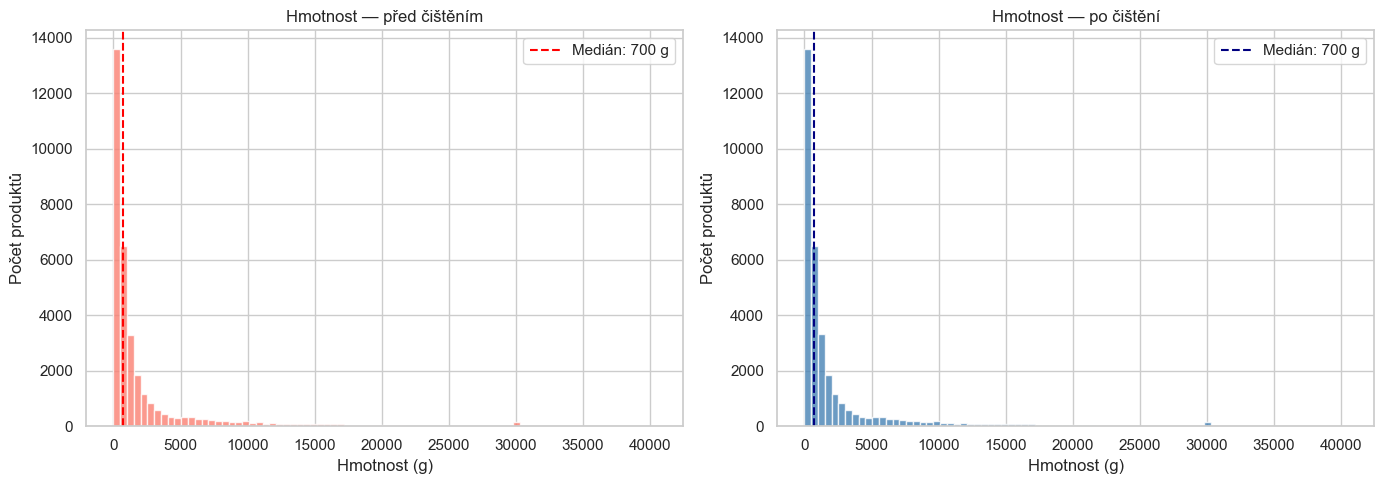

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_before["product_weight_g"].dropna(), bins=80, color="salmon", edgecolor="white", alpha=0.8)
axes[0].set_title("Hmotnost — před čištěním")
axes[0].set_xlabel("Hmotnost (g)")
axes[0].set_ylabel("Počet produktů")
axes[0].axvline(df_before["product_weight_g"].median(), color="red", ls="--", label=f'Medián: {df_before["product_weight_g"].median():.0f} g')
axes[0].legend()

axes[1].hist(df_after["product_weight_g"].dropna(), bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_title("Hmotnost — po čištění")
axes[1].set_xlabel("Hmotnost (g)")
axes[1].set_ylabel("Počet produktů")
axes[1].axvline(df_after["product_weight_g"].median(), color="navy", ls="--", label=f'Medián: {df_after["product_weight_g"].median():.0f} g')
axes[1].legend()

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_weight_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

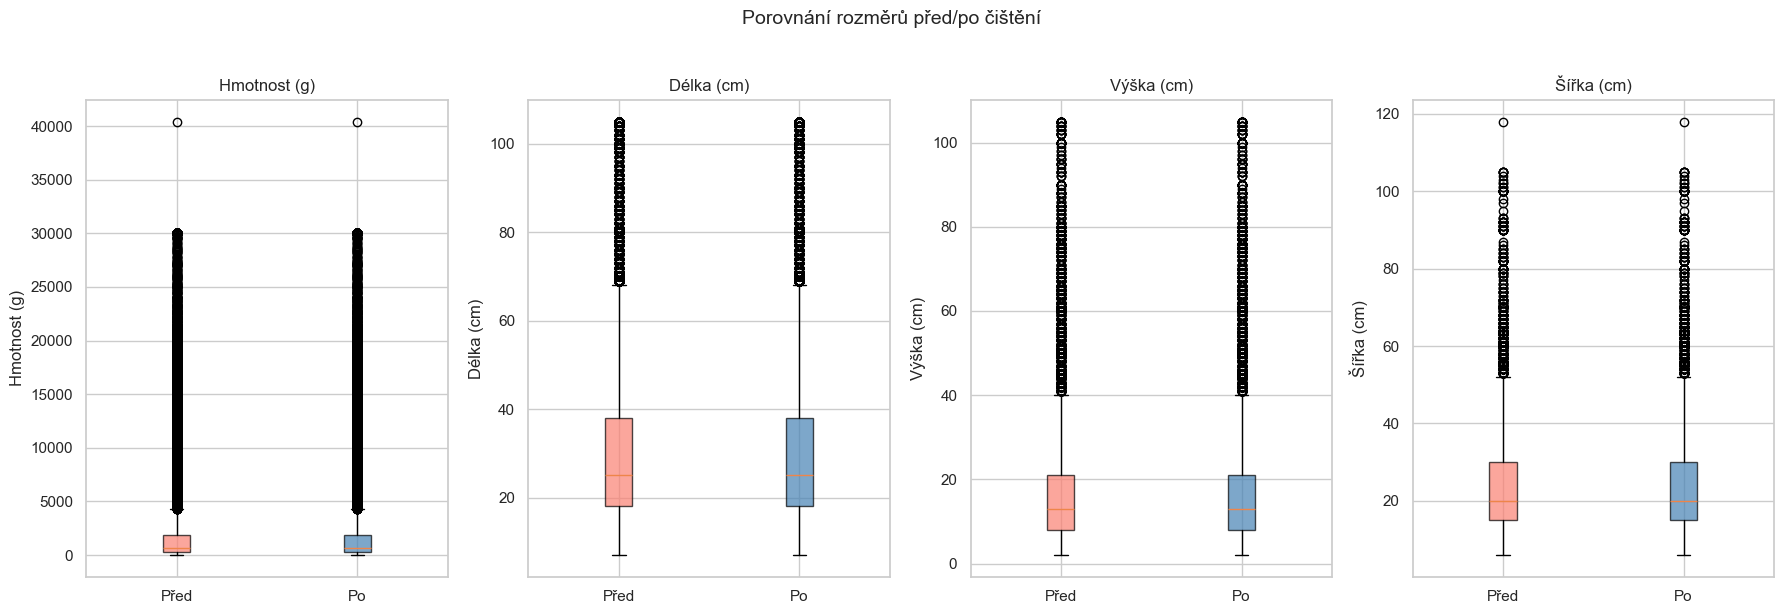

In [4]:
# Box ploty rozměrů před/po čištění
cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
titles = ["Hmotnost (g)", "Délka (cm)", "Výška (cm)", "Šířka (cm)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (col, title) in enumerate(zip(cols, titles)):
    data_to_plot = [
        df_before[col].dropna().values,
        df_after[col].dropna().values,
    ]
    bp = axes[i].boxplot(data_to_plot, tick_labels=["Před", "Po"], patch_artist=True,
                         boxprops=dict(alpha=0.7))
    bp["boxes"][0].set_facecolor("salmon")
    bp["boxes"][1].set_facecolor("steelblue")
    axes[i].set_title(title)
    axes[i].set_ylabel(title)

plt.suptitle("Porovnání rozměrů před/po čištění", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_dimensions_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Outlier analýza

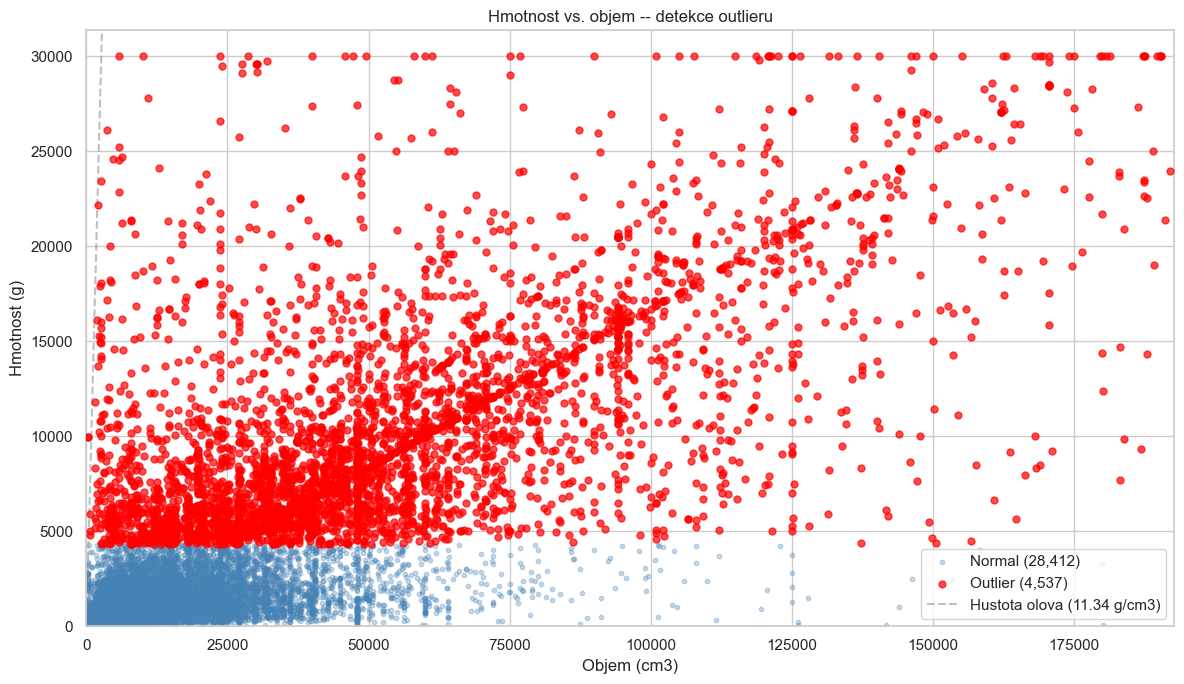

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

is_outlier = df_after["outlier_product_weight_g"] == True
normal = df_after[~is_outlier]
outliers = df_after[is_outlier]

ax.scatter(normal["volume_cm3"], normal["product_weight_g"],
           alpha=0.3, s=10, color="steelblue", label=f"Normal ({len(normal):,})")
ax.scatter(outliers["volume_cm3"], outliers["product_weight_g"],
           alpha=0.7, s=25, color="red", label=f"Outlier ({len(outliers):,})", zorder=5)

# Referencni cara hustoty olova
max_weight = df_after["product_weight_g"].max() * 1.1
max_vol_for_line = max_weight / 11.34  # objem kde cara dosahne max hmotnosti
vol_line = np.linspace(0, min(max_vol_for_line, df_after["volume_cm3"].max()), 100)
ax.plot(vol_line, vol_line * 11.34, color="gray", ls="--", alpha=0.5, label="Hustota olova (11.34 g/cm3)")

ax.set_xlabel("Objem (cm3)")
ax.set_ylabel("Hmotnost (g)")
ax.set_title("Hmotnost vs. objem -- detekce outlieru")
ax.legend()
ax.set_xlim(left=0, right=df_after["volume_cm3"].quantile(0.995) * 1.1)
ax.set_ylim(bottom=0, top=df_after["product_weight_g"].quantile(0.995) * 1.1)

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_outlier_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Odvozené příznaky

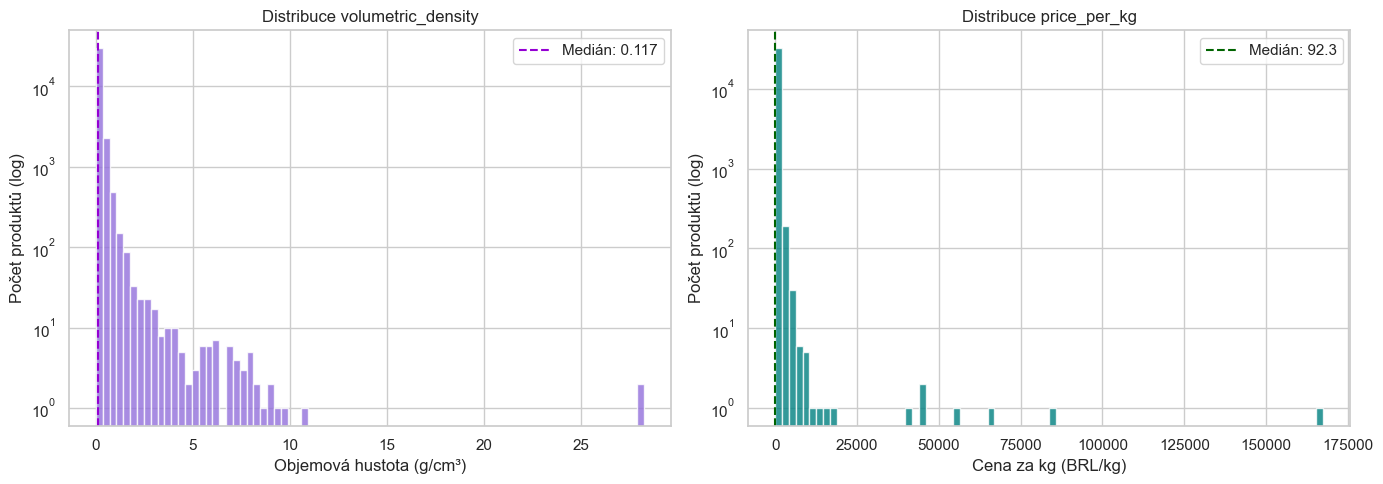

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_after["volumetric_density"].dropna(), bins=80, color="mediumpurple", edgecolor="white", alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Distribuce volumetric_density")
axes[0].set_xlabel("Objemová hustota (g/cm³)")
axes[0].set_ylabel("Počet produktů (log)")
axes[0].axvline(df_after["volumetric_density"].median(), color="darkviolet", ls="--",
                label=f'Medián: {df_after["volumetric_density"].median():.3f}')
axes[0].legend()

axes[1].hist(df_after["price_per_kg"].dropna(), bins=80, color="teal", edgecolor="white", alpha=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Distribuce price_per_kg")
axes[1].set_xlabel("Cena za kg (BRL/kg)")
axes[1].set_ylabel("Počet produktů (log)")
axes[1].axvline(df_after["price_per_kg"].median(), color="darkgreen", ls="--",
                label=f'Medián: {df_after["price_per_kg"].median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_derived_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Seskupeni kategorií

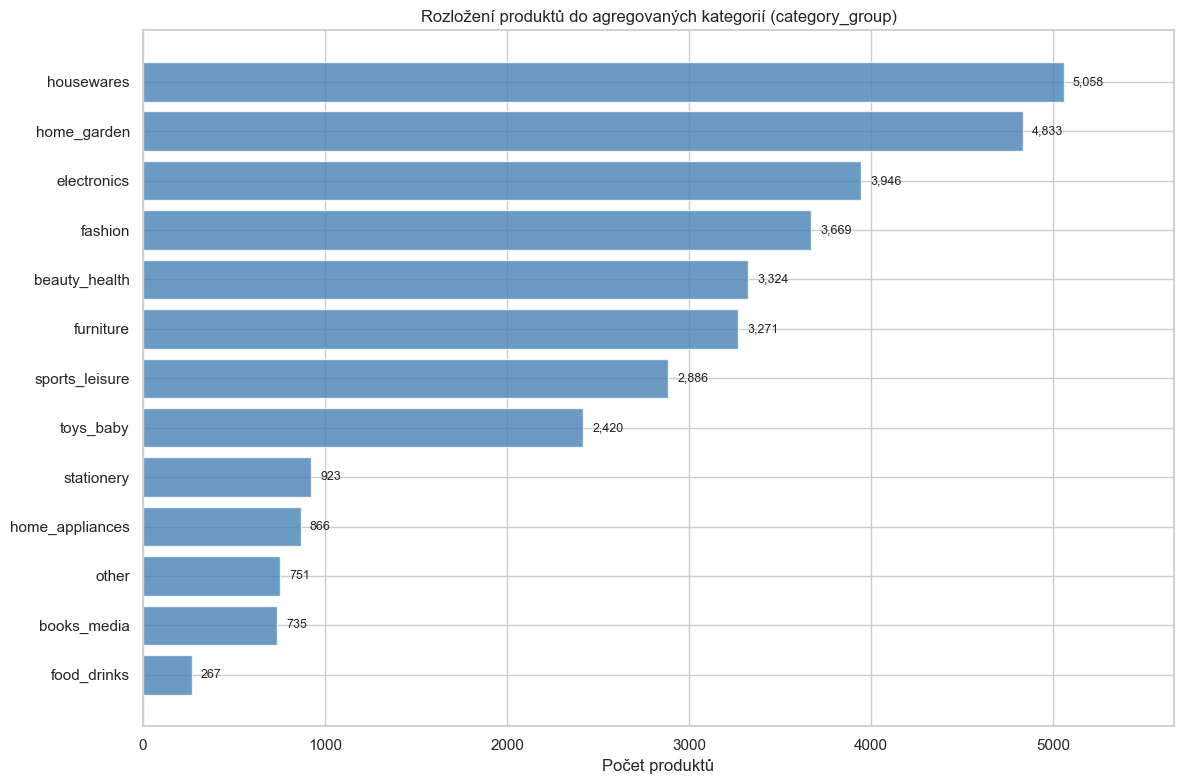

In [7]:
group_counts = df_after["category_group"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(group_counts.index, group_counts.values, color="steelblue", edgecolor="white", alpha=0.8)

for bar, val in zip(bars, group_counts.values):
    ax.text(val + group_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Počet produktů")
ax.set_title("Rozložení produktů do agregovaných kategorií (category_group)")
ax.set_xlim(right=group_counts.max() * 1.12)

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_category_groups.png", dpi=150, bbox_inches="tight")
plt.show()

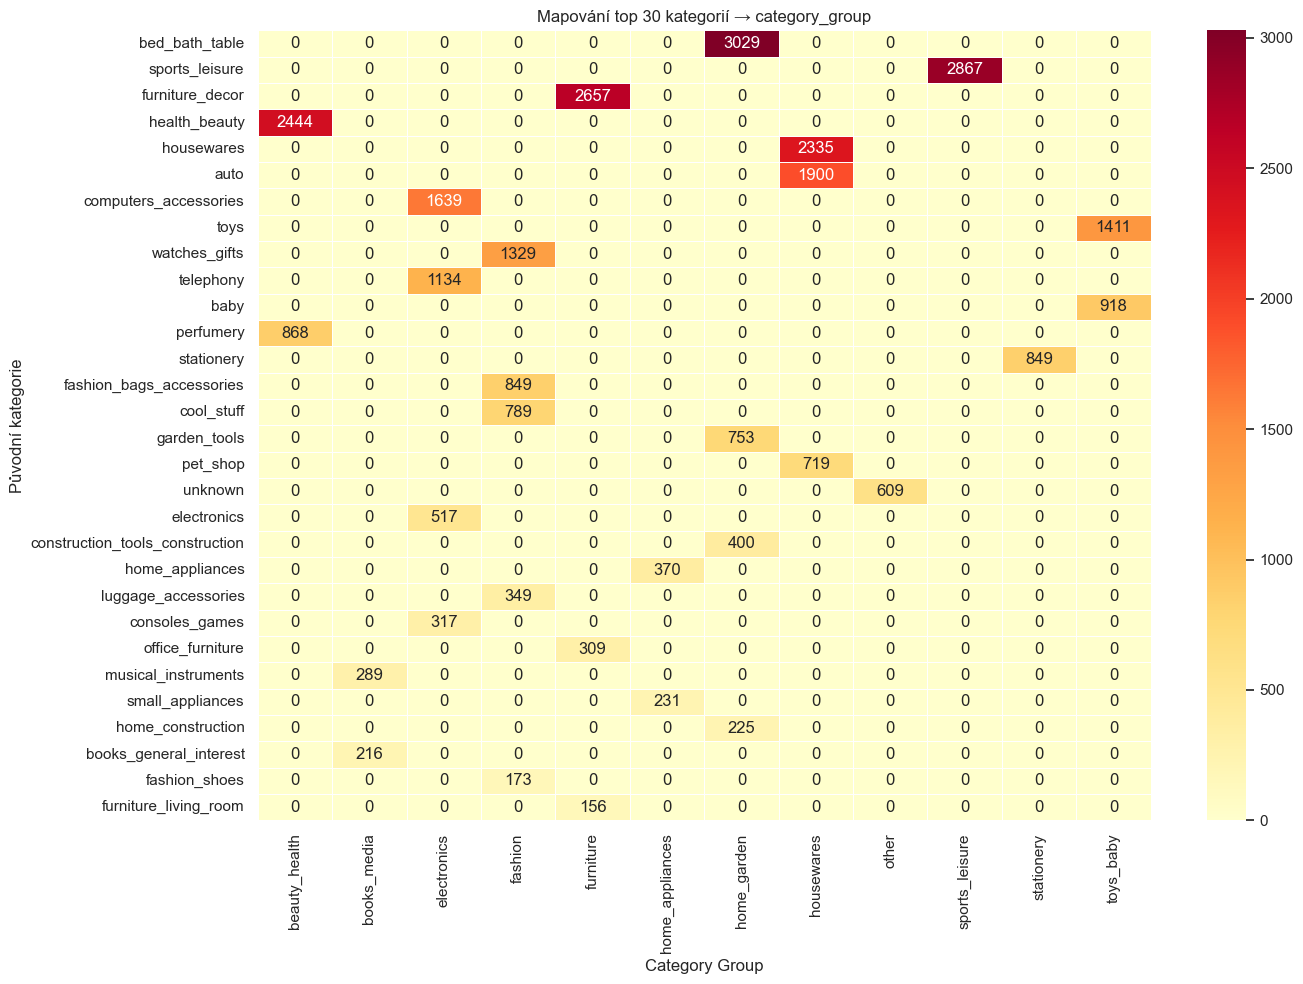

In [8]:
# Heatmapa
cat_col = "product_category_name_english"
top30 = df_after[cat_col].value_counts().head(30).index
df_top30 = df_after[df_after[cat_col].isin(top30)]

ct = pd.crosstab(df_top30[cat_col], df_top30["category_group"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Mapování top 30 kategorií → category_group")
ax.set_xlabel("Category Group")
ax.set_ylabel("Původní kategorie")

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_category_mapping.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Turnover — před/po doplnění

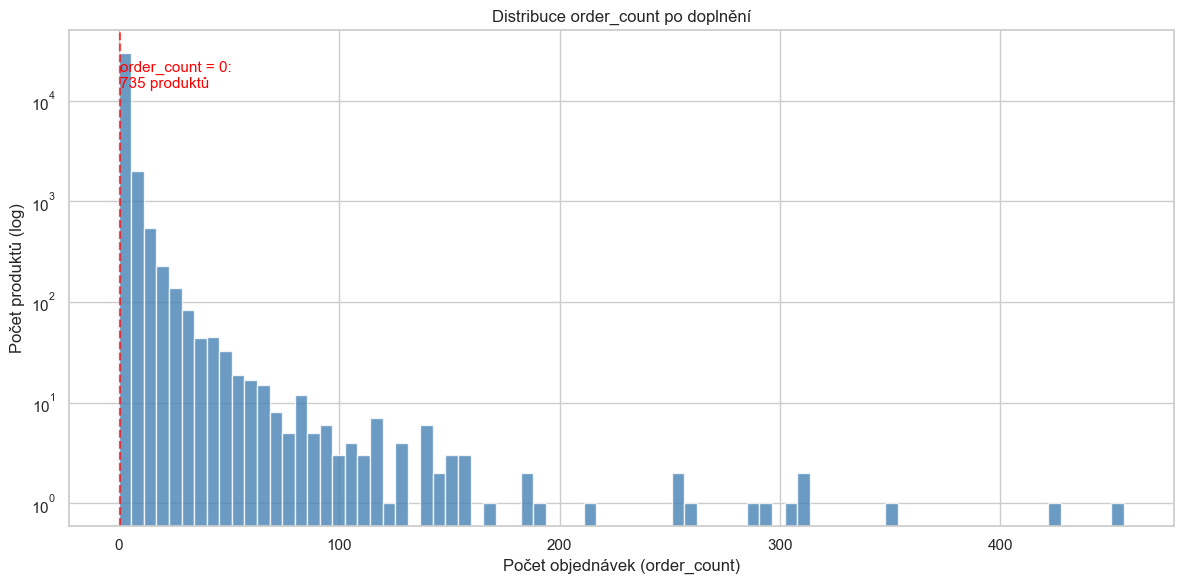

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

order_counts = df_after["order_count"].fillna(0)
zero_count = (order_counts == 0).sum()

ax.hist(order_counts, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_yscale("log")
ax.set_title("Distribuce order_count po doplnění")
ax.set_xlabel("Počet objednávek (order_count)")
ax.set_ylabel("Počet produktů (log)")

ax.axvline(0.5, color="red", ls="--", alpha=0.7)
ax.text(0.6, ax.get_ylim()[1] * 0.5, f"order_count = 0:\n{zero_count:,} produktů",
        color="red", fontsize=11, va="top")

plt.tight_layout()
plt.savefig("results/phase2_cleaning/cleaning_turnover_filled.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Shrnutí

In [10]:
print("SHRNUTÍ FÁZE 2: Čištění dat a agregace kategorií")
print("=" * 60)
print(f"Produktů před: {df_before.shape[0]:,}")
print(f"Produktů po: {df_after.shape[0]:,}")
print(f"Vyřazeno: {df_before.shape[0] - df_after.shape[0]}")
print(f"NaN ve fyzických: {df_after[['product_weight_g','product_length_cm','product_height_cm','product_width_cm']].isnull().sum().sum()}")
print(f"NaN v order_count: {df_after['order_count'].isnull().sum()}")
print(f"Kategoriálních skupin: {df_after['category_group'].nunique()}")
print(f"Nové sloupce: volume_cm3, volumetric_density, price_per_kg, category_group")
print(f"\nVýstup: data/processed/products_processed.csv")

SHRNUTÍ FÁZE 2: Čištění dat a agregace kategorií
Produktů před: 32,951
Produktů po: 32,949
Vyřazeno: 2
NaN ve fyzických: 0
NaN v order_count: 0
Kategoriálních skupin: 13
Nové sloupce: volume_cm3, volumetric_density, price_per_kg, category_group

Výstup: data/processed/products_processed.csv
